In [98]:
# 单元格 1：导入库、路径设置
import sys
import os
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# 项目根目录
project_root = os.path.abspath('../')
if project_root not in sys.path:
    sys.path.append(project_root)

# 处理后数据目录
PROCESSED_DIR = os.path.join(project_root, 'data', 'processed')

# 如果需要 SCP 语句映射文件，可以读取原始数据中的 scp_statements.csv
RAW_DATA_DIR = os.path.join(project_root, 'data', 'raw', 'ptb-xl_1.0.2')
SCP_STATEMENTS_PATH = os.path.join(RAW_DATA_DIR, 'scp_statements.csv')

In [99]:
# 单元格 2：加载标签 CSV
splits = ['train', 'val', 'test']
labels_dfs = {}
for split in splits:
    csv_path = os.path.join(PROCESSED_DIR, split, 'labels.csv')
    if os.path.exists(csv_path):
        labels_dfs[split] = pd.read_csv(csv_path)
        print(f"加载 {split} 集：{len(labels_dfs[split])} 条记录")
    else:
        print(f"警告：找不到 {csv_path}，请先运行 02_data_preprocessing")

加载 train 集：17181 条记录
加载 val 集：2136 条记录
加载 test 集：2161 条记录


In [100]:
# 单元格 3：解析 scp_codes 字符串为字典
def parse_scp_codes(scp_str):
    """将 scp_codes 的字符串形式转换为 Python 字典。
       例如 "{'NORM': 100.0, 'LVH': 0.0}" -> {'NORM': 100.0, 'LVH': 0.0}"""
    if isinstance(scp_str, str):
        try:
            # 使用 ast.literal_eval 安全解析
            return ast.literal_eval(scp_str)
        except (SyntaxError, ValueError):
            # 格式不对就返回空字典
            return {}
    elif isinstance(scp_str, dict):
        return scp_str
    else:
        return {}

# 应用到各划分集
for split, df in labels_dfs.items():
    df['scp_dict'] = df['scp_codes'].apply(parse_scp_codes)
    # 查看一下解析成功情况
    success = df['scp_dict'].apply(lambda x: isinstance(x, dict)).mean()
    print(f"{split} 集解析成功率: {success:.2%}")

train 集解析成功率: 100.00%
val 集解析成功率: 100.00%
test 集解析成功率: 100.00%


In [101]:
# 单元格 4：了解诊断标签的原始分布（最常见的 SCP 代码）
# 将所有 scp 代码聚合
all_scp_codes = []
all_scp_codes_pos = []
for df in labels_dfs.values():
    for scp_dict in df['scp_dict']:
        all_scp_codes.extend(list(scp_dict.keys()))
        all_scp_codes_pos.extend([k for k, v in scp_dict.items() if v > 0])

code_counts = Counter(all_scp_codes)
code_counts_pos = Counter(all_scp_codes_pos)
# 显示前 20 个最常见诊断（value>0）
print("前 20 个最常见 SCP 诊断码（按 value>0 出现次数）：")
for code, count in code_counts_pos.most_common(20):
    print(f"  {code}: {count}")

前 20 个最常见 SCP 诊断码：
  SR: 16561
  NORM: 9475
  ABQRS: 3286
  IMI: 2629
  ASMI: 2275
  LVH: 2084
  NDT: 1784
  LAFB: 1563
  AFIB: 1448
  ISC_: 1237
  PVC: 1110
  IRBBB: 1096
  STD_: 968
  VCLVH: 859
  STACH: 801
  IVCD: 772
  1AVB: 770
  SARRH: 763
  NST_: 736
  ISCAL: 642


In [102]:
# 单元格 5：定义任务所需的标签类型（根据需要选择）

# 方式 A：多标签分类（部分高频 SCP 代码）
# ⚠️ 修复：PTB-XL 的 scp_codes 中 value<=0 表示"明确排除/不存在"，
#    因此选类与编码都只统计 value>0 的码（旧版把 0 概率码误算为正例）。
# 选取 value>0 出现次数最多的前 N 个 SCP 代码作为标签
TOP_N = 10
top_codes = [code for code, _ in code_counts_pos.most_common(TOP_N)]
print(f"选取的多标签类别（top {TOP_N}，按 value>0 统计）：{top_codes}")

def encode_multilabel(scp_dict, code_list):
    """将 scp_dict 转换为多标签二值向量（仅 value>0 计为正例）"""
    return [1 if scp_dict.get(code, 0) > 0 else 0 for code in code_list]

# 为每个划分集生成多标签矩阵
multilabel_data = {}
for split, df in labels_dfs.items():
    multilabel_matrix = np.array([encode_multilabel(d, top_codes) for d in df['scp_dict']])
    multilabel_data[split] = multilabel_matrix
    print(f"{split} 集多标签形状: {multilabel_matrix.shape}")
    # 统计每个类别的正例数
    pos_counts = multilabel_matrix.sum(axis=0)
    print(f"  各类别正例数: {dict(zip(top_codes, pos_counts))}")

选取的多标签类别（top 10）：['SR', 'NORM', 'ABQRS', 'IMI', 'ASMI', 'LVH', 'NDT', 'LAFB', 'AFIB', 'ISC_']
train 集多标签形状: (17181, 10)
  各类别正例数: {'SR': np.int64(13254), 'NORM': np.int64(7562), 'ABQRS': np.int64(2657), 'IMI': np.int64(2107), 'ASMI': np.int64(1829), 'LVH': np.int64(1672), 'NDT': np.int64(1429), 'LAFB': np.int64(1257), 'AFIB': np.int64(1167), 'ISC_': np.int64(996)}
val 集多标签形状: (2136, 10)
  各类别正例数: {'SR': np.int64(1652), 'NORM': np.int64(952), 'ABQRS': np.int64(312), 'IMI': np.int64(260), 'ASMI': np.int64(220), 'LVH': np.int64(203), 'NDT': np.int64(179), 'LAFB': np.int64(152), 'AFIB': np.int64(137), 'ISC_': np.int64(119)}
test 集多标签形状: (2161, 10)
  各类别正例数: {'SR': np.int64(1655), 'NORM': np.int64(961), 'ABQRS': np.int64(317), 'IMI': np.int64(262), 'ASMI': np.int64(226), 'LVH': np.int64(209), 'NDT': np.int64(176), 'LAFB': np.int64(154), 'AFIB': np.int64(144), 'ISC_': np.int64(122)}


In [103]:
# 单元格 6：方式 B：诊断大类分类（与 PTB‑XL 官方一致的加权规则）

scp_statements = pd.read_csv(SCP_STATEMENTS_PATH, index_col=0)
scp_to_class = scp_statements['diagnostic_class'].to_dict()

# 🔨 只修复确认缺失的诊断码
FIX_MAP = {
    'ABQRS': 'CD', 'STD_': 'STTC', 'NST_': 'STTC', 'NT_': 'STTC',
    'INVT': 'STTC', 'TAB_': 'STTC', 'LOWT': 'STTC', 'QWAVE': 'MI',
    'ISC_': 'MI', 'ISCAL': 'MI', 'LPR': 'STTC', 'LVOLT': 'HYP',
    'PRC(S)':'CD', 'PACE': 'CD', 'VCLVH': 'HYP', 'HVOLT': 'HYP',
    'STE_': 'STTC', 'PSVT': 'STTC',
}
for code, cls in FIX_MAP.items():
    scp_to_class[code] = cls

def get_diagnostic_class_from_scp(scp_dict: dict) -> str:
    """
    PTB‑XL 官方规则：
    1. 汇总各类别概率。
    2. 🔑 NORM 若与其他诊断类共存 → 直接排除 NORM。
    3. 剩余类中选概率最大者；平局按 MI > CD > STTC > HYP > NORM。
    """
    class_prob = {}
    for code, prob in scp_dict.items():
        cls = scp_to_class.get(code, None)
        if cls is None or pd.isna(cls):
            continue
        class_prob[cls] = class_prob.get(cls, 0.0) + float(prob)

    if not class_prob:
        return 'OTHER'

    # 🔑 关键：NORM 与其他类共存 → 排除 NORM
    if 'NORM' in class_prob and len(class_prob) > 1:
        del class_prob['NORM']

    max_prob = max(class_prob.values())
    max_classes = [c for c, p in class_prob.items() if p == max_prob]
    for cls in ['MI', 'CD', 'STTC', 'HYP', 'NORM']:
        if cls in max_classes:
            return cls
    return max_classes[0]

for split, df in labels_dfs.items():
    df['diagnostic_class'] = df['scp_dict'].apply(get_diagnostic_class_from_scp)
    print(f"\n{split} 集诊断大类分布（单标签）：")
    print(df['diagnostic_class'].value_counts())


train 集诊断大类分布（单标签）：
diagnostic_class
NORM     6739
MI       4282
CD       3194
STTC     2176
HYP       720
OTHER      70
Name: count, dtype: int64

val 集诊断大类分布（单标签）：
diagnostic_class
NORM     784
MI       513
CD       458
STTC     274
HYP      102
OTHER      5
Name: count, dtype: int64

test 集诊断大类分布（单标签）：
diagnostic_class
NORM     815
MI       537
CD       430
STTC     270
HYP       99
OTHER     10
Name: count, dtype: int64


In [104]:
# 单元格 7：保存处理后的标签
OUTPUT_LABEL_DIR = os.path.join(PROCESSED_DIR, 'labels')
os.makedirs(OUTPUT_LABEL_DIR, exist_ok=True)

for split, df in labels_dfs.items():
    # 保存多标签矩阵
    if split in multilabel_data:
        np.save(
            os.path.join(OUTPUT_LABEL_DIR, f'{split}_multilabel.npy'),
            multilabel_data[split],
            allow_pickle=False             # 纯数值数组，关闭 pickle 更安全
        )                                  # 移除已弃用的 fix_imports 参数

    # 保存扩展后的 DataFrame
    cols_to_save = ['scp_codes', 'strat_fold', 'report', 'diagnostic_class']
    available_cols = [c for c in cols_to_save if c in df.columns]
    df_save = df[available_cols + ['scp_dict']]
    df_save.to_csv(
        os.path.join(OUTPUT_LABEL_DIR, f'{split}_labels_parsed.csv'),
        index=False
    )

print("✅ 标签解析完成，文件保存至:", OUTPUT_LABEL_DIR)

✅ 标签解析完成，文件保存至: d:\Code (VS Code)\EGC_Model\data\processed\labels


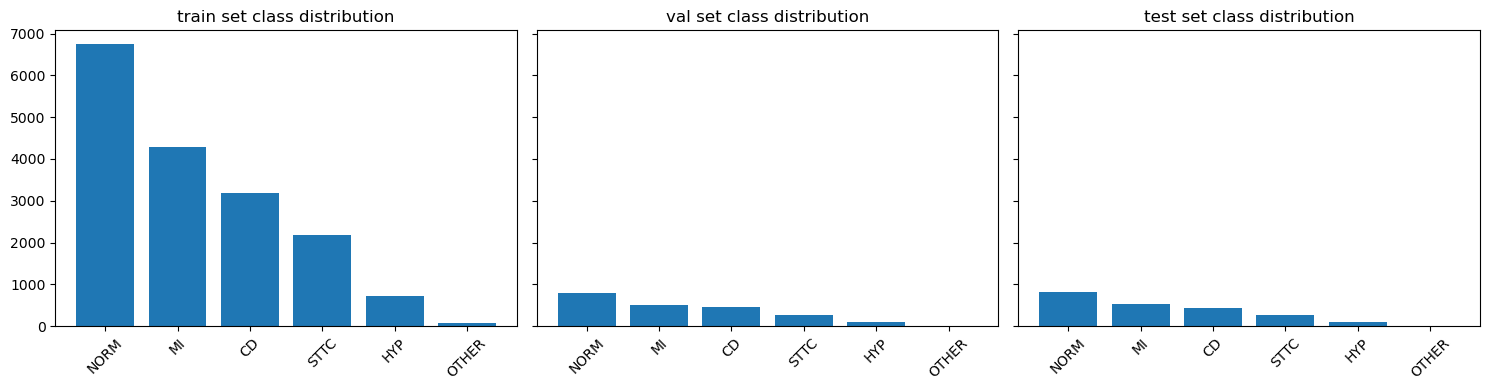

In [105]:
# 单元格 8：可视化标签分布（可选）
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, (split, df) in enumerate(labels_dfs.items()):
    ax = axes[i]
    class_counts = df['diagnostic_class'].value_counts()
    ax.bar(class_counts.index, class_counts.values)
    ax.set_title(f'{split} set class distribution')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [106]:
# 单元格：精简版 fix_map + 多标签对比
import pandas as pd
import numpy as np

# 读取官方 SCP 语句映射
scp_statements = pd.read_csv(SCP_STATEMENTS_PATH, index_col=0)
scp_to_class = scp_statements['diagnostic_class'].to_dict()

# ⚠️ 只补充 PTB-XL 论文附录/官方文档中明确属于这些超类、但 scp_statements 遗漏的代码
FIX_MAP = {
    # ST/T 变化 (STTC)
    'STD_': 'STTC',   # 非特异性 ST 压低
    'NST_': 'STTC',   # 非特异性 ST-T 改变
    'NT_':  'STTC',   # 非特异性 T 波改变
    'TAB_': 'STTC',   # T 波异常
    'INVT': 'STTC',   # T 波倒置
    'LOWT': 'STTC',   # 低电压 T 波
    # 心肌梗死 (MI)
    'QWAVE': 'MI',    # 异常 Q 波
}
# 只更新那些 scp_statements 中原本缺失的代码
for code, cls in FIX_MAP.items():
    if code not in scp_to_class or pd.isna(scp_to_class[code]):
        scp_to_class[code] = cls

# 重新计算各 split 的诊断大类（如果需要多标签，直接统计即可）
ALL_CLASSES = ['NORM', 'MI', 'CD', 'STTC', 'HYP']

print("各类别占比对比（PhysioNet 官方多标签 vs 当前计算，多标签统计）：")
for split, df in labels_dfs.items():
    print(f"\n{split} 集 ({len(df)} 条):")
    multilabel_counts = {c: 0 for c in ALL_CLASSES}
    for scp_dict in df['scp_dict']:
        classes_present = set()
        for code in scp_dict:
            cls = scp_to_class.get(code, None)
            # 只计入五大超类，缺失映射的代码归入 OTHER，不参与计数
            if cls in ALL_CLASSES:
                classes_present.add(cls)
        for c in classes_present:
            multilabel_counts[c] += 1

    official_counts = {'NORM':9514, 'MI':5469, 'CD':4898, 'STTC':5235, 'HYP':2649}
    total_official = 21837
    for cls in ALL_CLASSES:
        expected = official_counts[cls] / total_official
        actual = multilabel_counts[cls] / len(df)
        diff = actual - expected
        match_icon = "✅" if abs(diff) < 0.05 else "⚠️"
        print(f"  {cls:6s}: 官方多标签 ≈ {expected:.1%}, 当前多标签 = {actual:.1%}  (偏差 {diff:+.1%}) {match_icon}")

各类别占比对比（PhysioNet 官方多标签 vs 当前计算，多标签统计）：

train 集 (17181 条):
  NORM  : 官方多标签 ≈ 43.6%, 当前多标签 = 44.0%  (偏差 +0.4%) ✅
  MI    : 官方多标签 ≈ 25.0%, 当前多标签 = 25.5%  (偏差 +0.4%) ✅
  CD    : 官方多标签 ≈ 22.4%, 当前多标签 = 22.1%  (偏差 -0.3%) ✅
  STTC  : 官方多标签 ≈ 24.0%, 当前多标签 = 26.2%  (偏差 +2.3%) ✅
  HYP   : 官方多标签 ≈ 12.1%, 当前多标签 = 12.1%  (偏差 -0.1%) ✅

val 集 (2136 条):
  NORM  : 官方多标签 ≈ 43.6%, 当前多标签 = 44.6%  (偏差 +1.0%) ✅
  MI    : 官方多标签 ≈ 25.0%, 当前多标签 = 24.6%  (偏差 -0.4%) ✅
  CD    : 官方多标签 ≈ 22.4%, 当前多标签 = 21.9%  (偏差 -0.5%) ✅
  STTC  : 官方多标签 ≈ 24.0%, 当前多标签 = 26.6%  (偏差 +2.7%) ✅
  HYP   : 官方多标签 ≈ 12.1%, 当前多标签 = 12.1%  (偏差 -0.1%) ✅

test 集 (2161 条):
  NORM  : 官方多标签 ≈ 43.6%, 当前多标签 = 44.5%  (偏差 +0.9%) ✅
  MI    : 官方多标签 ≈ 25.0%, 当前多标签 = 25.4%  (偏差 +0.3%) ✅
  CD    : 官方多标签 ≈ 22.4%, 当前多标签 = 22.3%  (偏差 -0.2%) ✅
  STTC  : 官方多标签 ≈ 24.0%, 当前多标签 = 25.9%  (偏差 +1.9%) ✅
  HYP   : 官方多标签 ≈ 12.1%, 当前多标签 = 11.9%  (偏差 -0.2%) ✅
